In [2]:
import os
from pathlib import Path
import torch 
import numpy as np

from ml.inference import load_checkpoint

## On charge le modèle MAEv1 après premier run de préentrainement
base = Path.cwd()

ckpt_dir = Path(os.path.join(base, '..', '..', 'outputs', 'ml', 'pretrain', '2026-08-05_13-36-04', 'checkpoints', 'best.pt'))

device = torch.device("cpu")
pretrained_model, cfg, mean, scale = load_checkpoint(ckpt_dir, device)
print(pretrained_model)


TimeSeriesMAE(
  (patch_embedding): PatchEmbedding(
    (proj): Conv1d(11, 64, kernel_size=(12,), stride=(12,))
  )
  (encoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(8, 64)
  )
  (decoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(9, 32)
  )
  (encoder_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (MSA): MultiHeadSelfAttention(
        (query_matrix): Linear(in_features=64, out_features=64, bias=True)
        (key_matrix): Linear(in_features=64, out_features=64, bias=True)
        (value_matrix): Linear(in_features=64, out_features=64, bias=True)
        (output_proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (MLP): MLP(
        (dense1): Linear(in_features=64, out_features=256, bias=True)
        (d

In [3]:
## on charge les poids de l'encoder du modèle préentrainé sur un backbone avec les mêmes paramètres (cf MAEv1.yaml pour l'archi de l'encoder)
from ml.model import VanillaViT

encoder_sd = pretrained_model.encoder_state_dict() ## donne directement les poids de l'encodeur avec les bons mapping


backbone_MAEv1 = VanillaViT(
    n_features = 11, 
    n_epochs= 96, 
    patch_size=12, 
    embed_dim=64,
    n_attn_heads=4,
    n_blocks=4,
    expansion_factor=4,
    dropout_rate=0.1
)
missing, unexpected = backbone_MAEv1.load_state_dict(encoder_sd, strict=False) # les poids sont bien chargés. 


In [15]:
from ml.datahandler import load_spacetrack_objects, build_features

def load_data_and_inference(backbone):
    data_dir = Path(os.path.join(base, '..' , '..', 'data', 'raw', 'spacetrack'))
    objects = load_spacetrack_objects(data_dir)

    per_obj = {}
    for key, df in objects.items(): 
        features, feature_cols = build_features(df, spacetrack=True)
        X = (features[feature_cols].to_numpy(np.float32) - mean) / scale
        per_obj[key] = X

    backbone.eval()
    backbone.to(device)

    window_size = 96 
    batch_size = 256

    out = {}
    for norad, X in per_obj.items():
        if len(X) < window_size : 
            continue 
        stride = 24
        windows = np.lib.stride_tricks.sliding_window_view(X, window_size, axis=0)[::stride] # (L,F,W)

        cls_representations = []

        for i in range(0, len(windows), batch_size): 
            x = torch.from_numpy(np.ascontiguousarray(windows[i:i+batch_size])).float().to(device)

            with torch.no_grad(): 
                representation = backbone(x)
            cls_representations.append(representation[:,0,:].cpu().numpy()) ## on ne stocke que le cls token

        if cls_representations:
            out[norad] = np.concatenate(cls_representations, axis=0).mean(axis=0) 
    return out 


out_64 = load_data_and_inference(backbone_MAEv1)


In [16]:
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## une représentation par objet : token CLS (indice 0) moyenné sur toutes les fenêtres
norad_ids = list(out_64.keys())
X_obj = np.stack([out_64[n] for n in norad_ids])
X_scaled = StandardScaler().fit_transform(X_obj)

clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=15)

labels = clusterer.fit_predict(X_scaled)

n_clusters = len(set(labels))



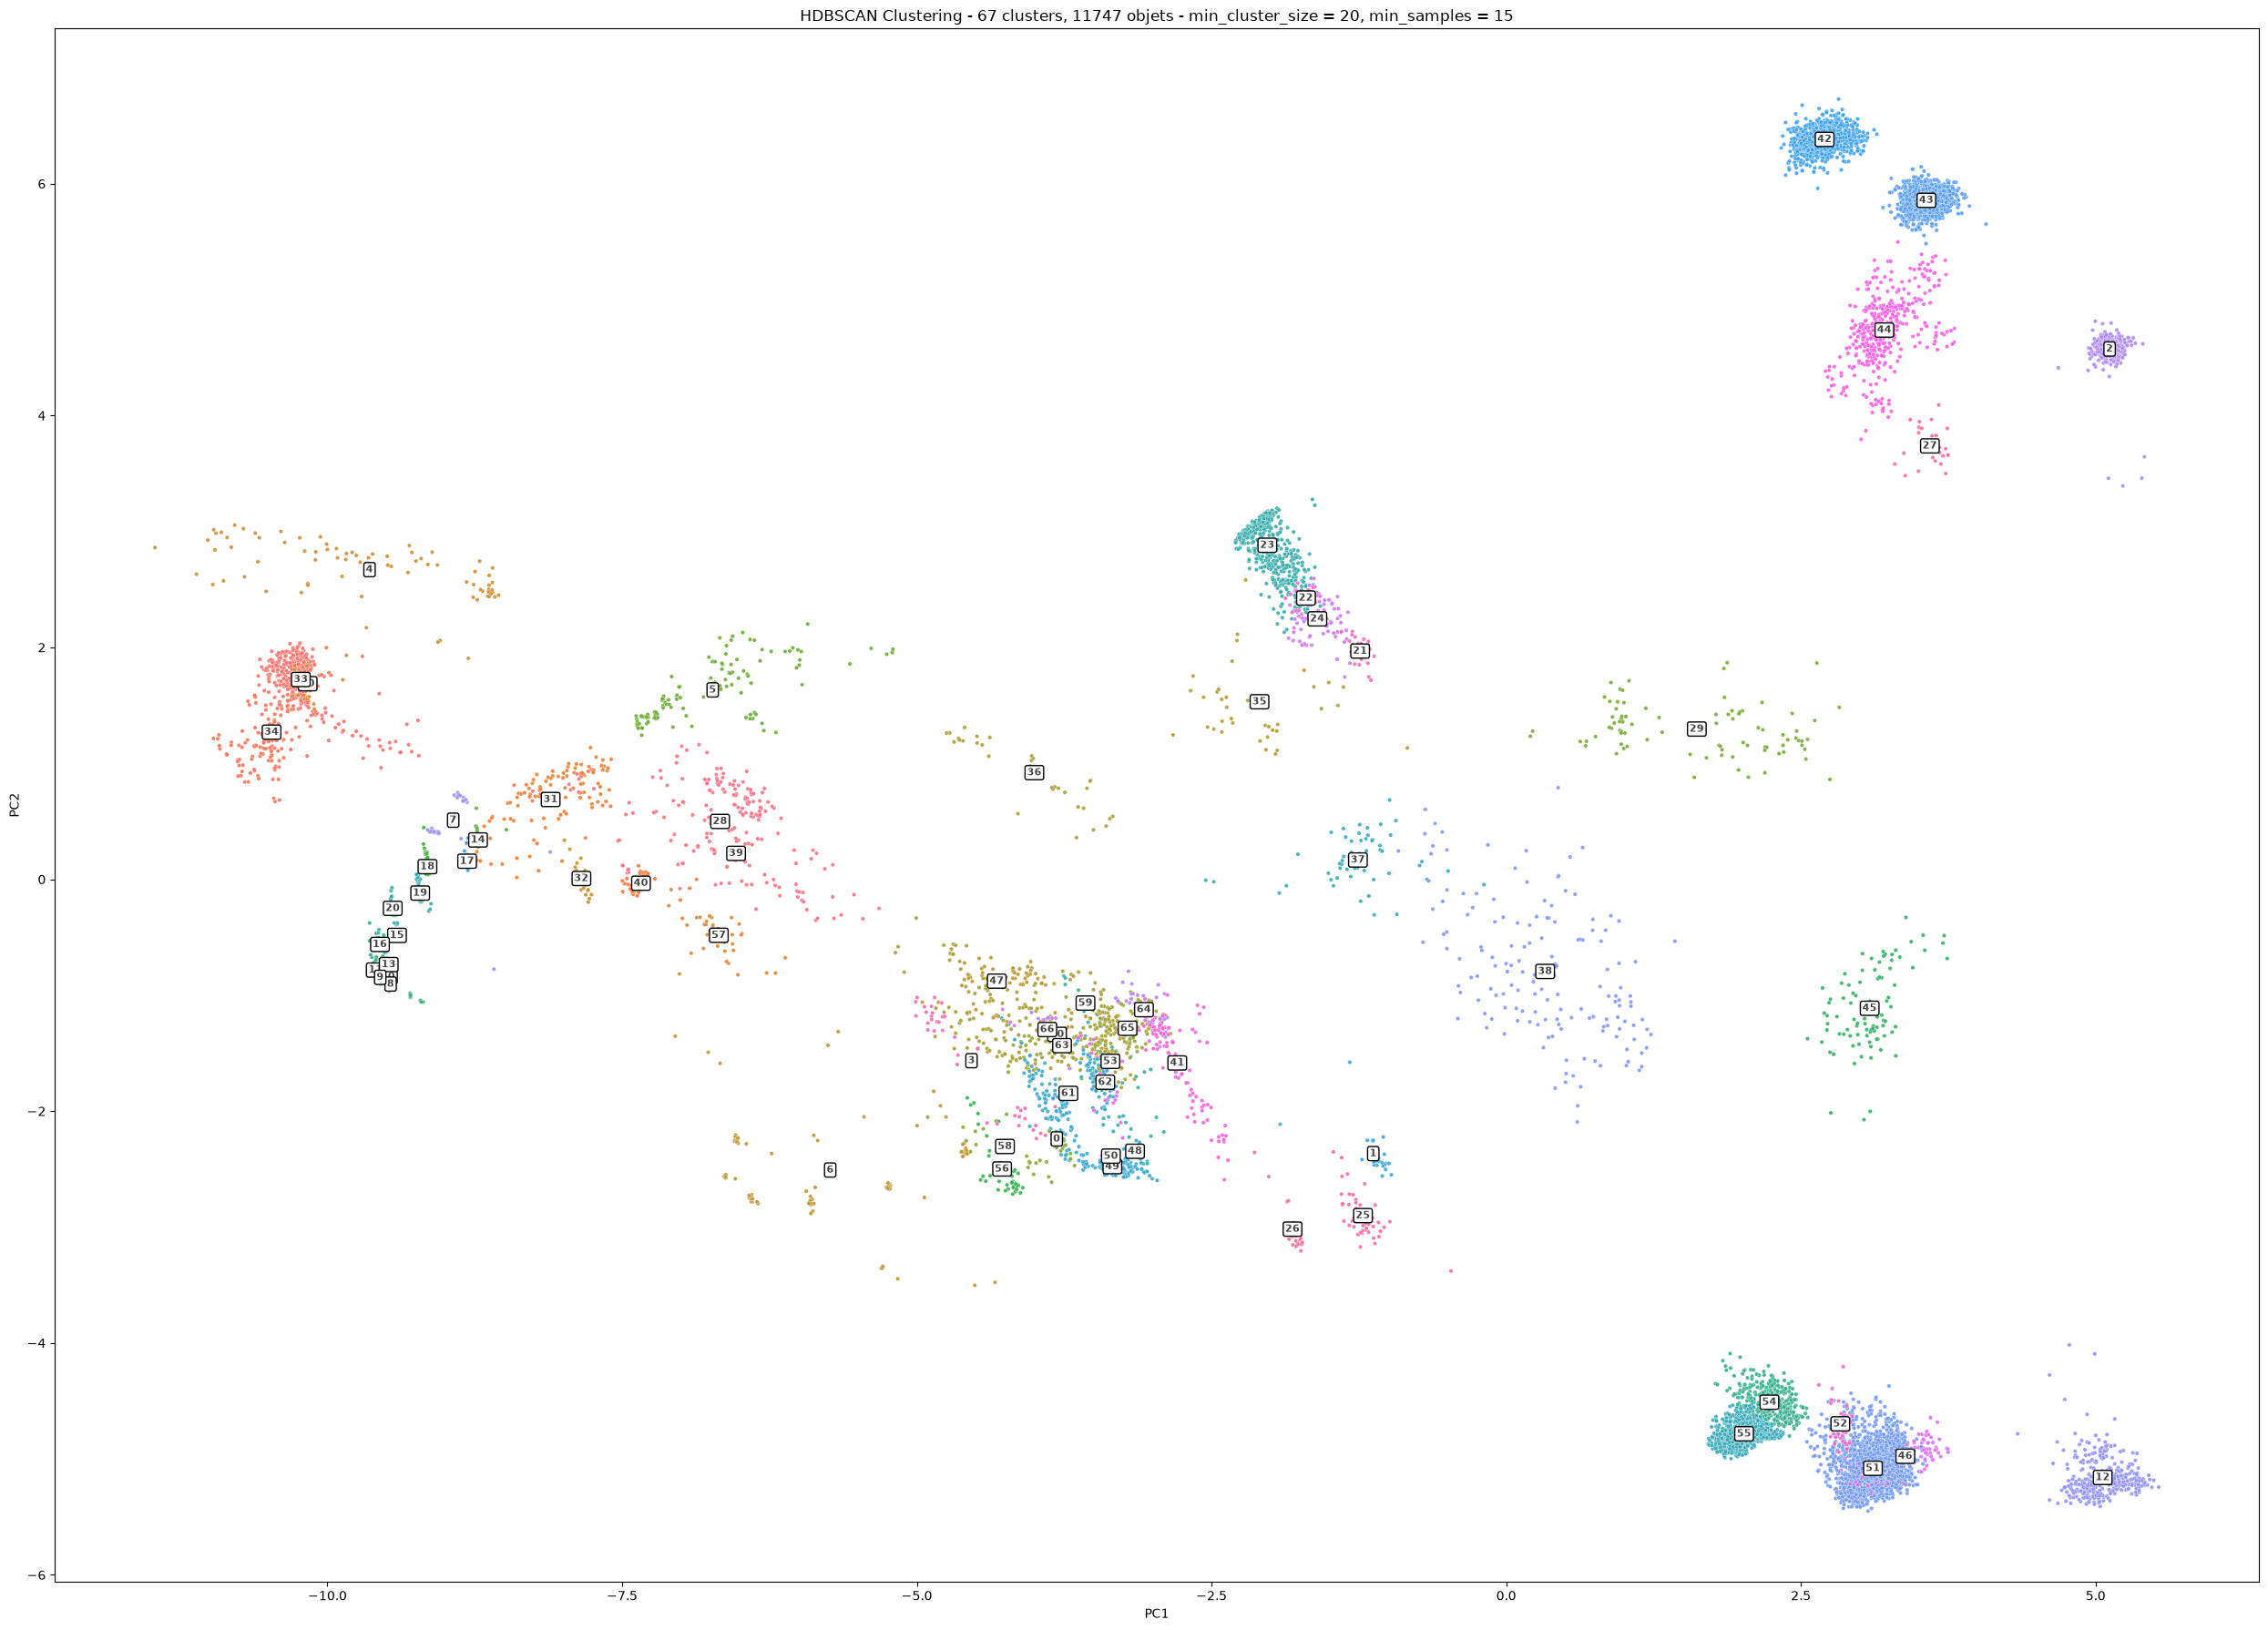

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## on retire les objets non clusterisés
mask = labels != -1
X_clean = X_scaled[mask]
labels_clean= labels[mask]
norad_clean = [norad_ids[i] for i in range(len(norad_ids)) if mask[i]]


def viz_3d_on_clusters(X, labels, min_cluster_size=20, min_samples=15):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 3 with principal components analysis, and show the clusters
    """
    pca = PCA(n_components=3)
    X_3d = pca.fit_transform(X)

    df = pd.DataFrame({'x' : X_3d[:,0], 'y' : X_3d[:,1], 'z': X_3d[:,2], 'cluster' : labels.astype(str)})
    
    fig, ax = plt.subplots(figsize=(25,18))

    sns.scatterplot(data=df , x='x',y='y', z = 'z', hue='cluster', palette='husl', s=10, alpha=0.9, legend=False, ax=ax)

    for cluster_id, group in df.groupby('cluster'):
        cx,cy,cz = group['x'].mean(), group['y'].mean(), group['z'].mean()
        ax.annotate(str(cluster_id), (cx,cy,cz), fontsize=8, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2' , fc ='white', ec='black'), alpha = 0.75)

    ax.set_title(f"HDBSCAN Clustering - {len(set(labels))} clusters, {len(labels)} objets - min_cluster_size = {min_cluster_size}, min_samples = {min_samples}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    

    plt.tight_layout()
    plt.show()

def viz_2d_on_clusters(X, labels, min_cluster_size = 20, min_samples=15, plot=True):
    """X is a (14 993, 64) ndarray of already scaled vectors, we reduce the dimension from 64 to 2 with principal components analysis, and show the clusters
    """
    if len(X[0]) > 2 : 
        pca = PCA(n_components=2, svd_solver='full')
        X_2d = pca.fit_transform(X)
    else : 
        X_2d = X
    df = pd.DataFrame({'x' : X_2d[:,0], 'y' : X_2d[:,1], 'cluster' : labels.astype(str)})
    
    fig, ax = plt.subplots(figsize=(25,18))

    sns.scatterplot(data=df , x='x',y='y',hue='cluster', palette='husl', s=10, alpha=0.9, legend=False, ax=ax)

    for cluster_id, group in df.groupby('cluster'):
        cx,cy = group['x'].mean(), group['y'].mean()
        ax.annotate(str(cluster_id), (cx,cy), fontsize=8, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2' , fc ='white', ec='black'), alpha = 0.75)

    ax.set_title(f"HDBSCAN Clustering - {len(set(labels))} clusters, {len(labels)} objets - min_cluster_size = {min_cluster_size}, min_samples = {min_samples}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    
    plt.tight_layout()
    plt.show()

viz_2d_on_clusters(X_clean, labels_clean)




In [18]:

## il s'avère que le cluster 38 est composé de Starlink 548xx à 587xx 
cluster_38 = [norad_ids[i] for i in range(len(norad_ids)) if labels[i] == 38]
X_cluster_38 = [X_scaled[i] for i in range(len(norad_ids)) if labels[i]  ==38]

cluster_38 = [norad_ids[i] for i in range(len(norad_ids)) if labels[i] == 38]
X_cluster_38 = [X_scaled[i] for i in range(len(norad_ids)) if labels[i]  ==38]
print(cluster_38)
print(len(cluster_38))

[57693, 63724, 63725, 63726, 63727, 63728, 63729, 63730, 63731, 63732, 63733, 63734, 63735, 63736, 63737, 63738, 63739, 63740, 63741, 63742, 63743, 63744, 63746, 63747, 63748, 63749, 63750, 64500, 64501, 64502, 64503, 64504, 64505, 64506, 64507, 64508, 64509, 64510, 64511, 64513, 64514, 64515, 64516, 64517, 64518, 64519, 64520, 64521, 64522, 64523, 64524, 64525, 64816, 64817, 64818, 64819, 64820, 64823, 64824, 64825, 64826, 64827, 64828, 64829, 64830, 64831, 64832, 64833, 64834, 64835, 64836, 64837, 64838, 64839, 65132, 65133, 65134, 65135, 65136, 65137, 65138, 65139, 65140, 65141, 65142, 65143, 65144, 65145, 65146, 65147, 65148, 65149, 65150, 65151, 65152, 65153, 65154, 65155, 65762, 65764, 65765, 65766, 65767, 65768, 65770, 65771, 65772, 65773, 65775, 65776, 65778, 65779, 65780, 65781, 65782, 65783, 65785, 65786, 65787, 65788, 65947, 65948, 65949, 65950, 65951, 65952, 65953, 65954, 65955, 65957, 65958, 65959, 65961, 65962, 65963, 65964, 65965, 65966, 65967, 65968, 65969, 65970, 67136

In [19]:
def create_cluster_csv(norad_ids, labels, name):
    # X est un vecteur de dim 64 représentant un unique satellite (moyenne des cls tokens des différentes fenêtres de l'objet)
    df = pd.DataFrame({
        'norad' : norad_ids, 'cluster' : labels
    })
    out_path = Path(base) / '..' / '..' / 'outputs' / 'clustering' / f'cluster_leo_{name}.csv'
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path , index=False)

create_cluster_csv(norad_ids, labels, 'all_dataset')

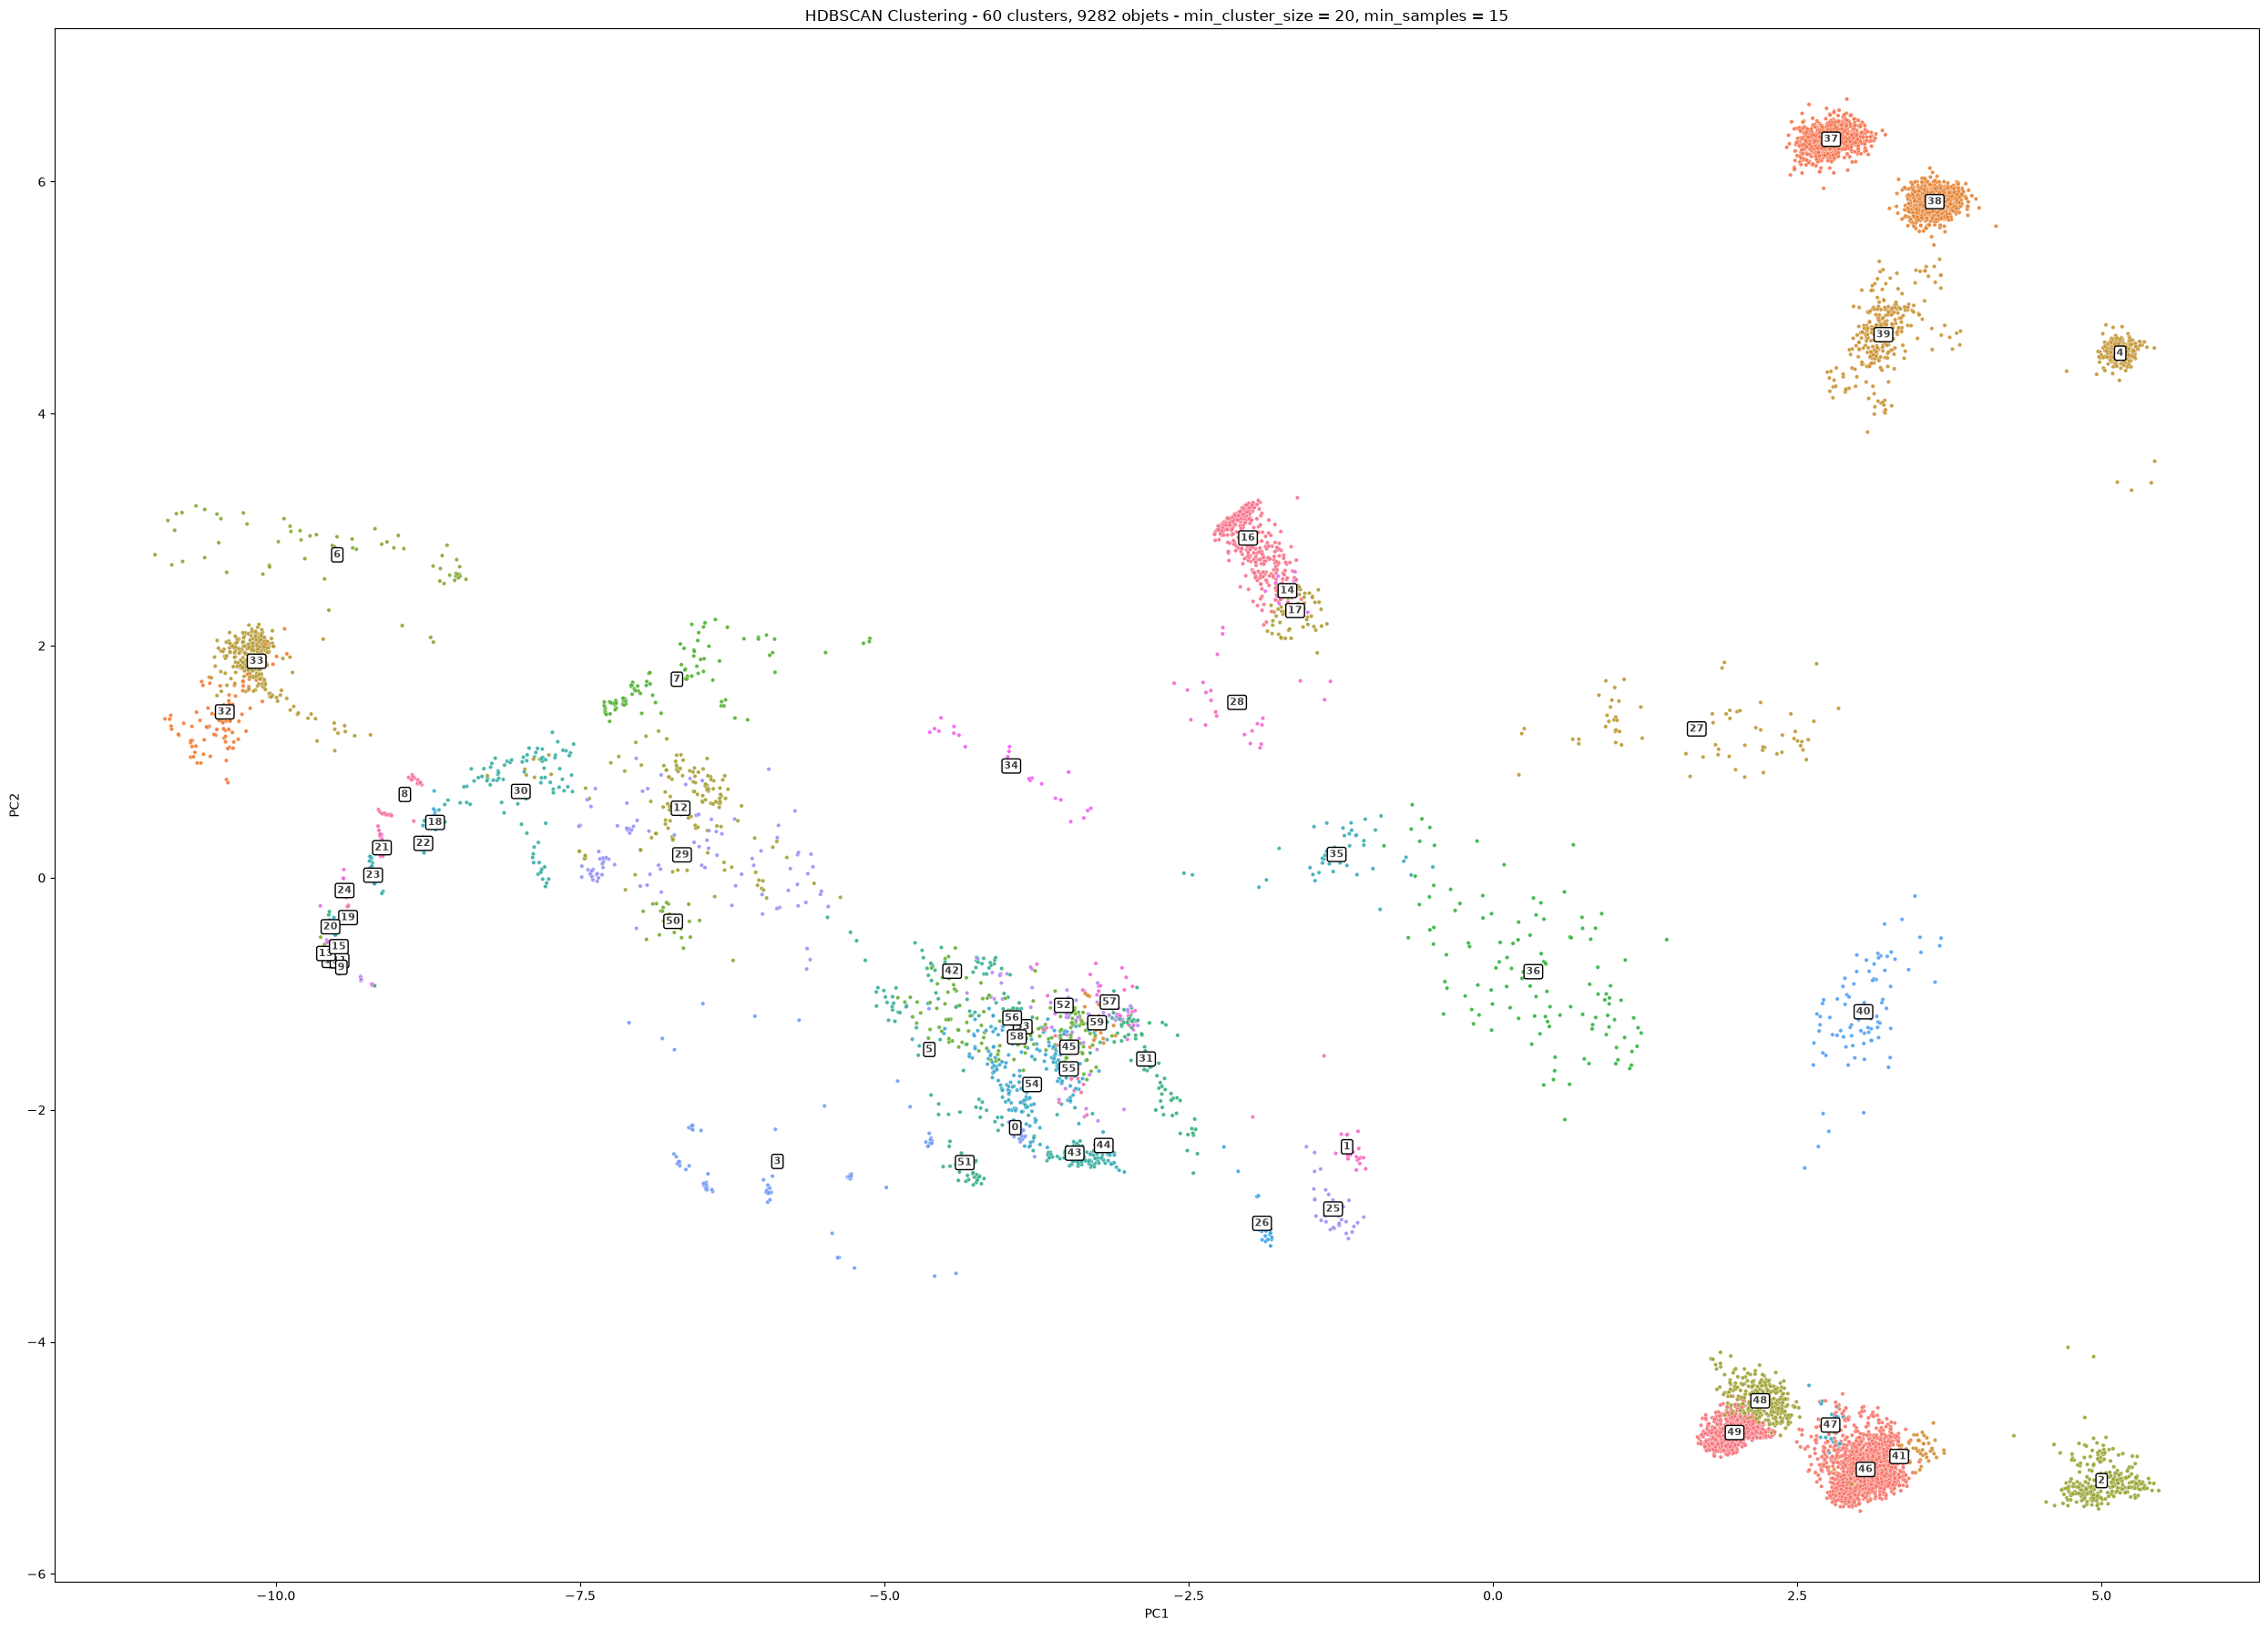

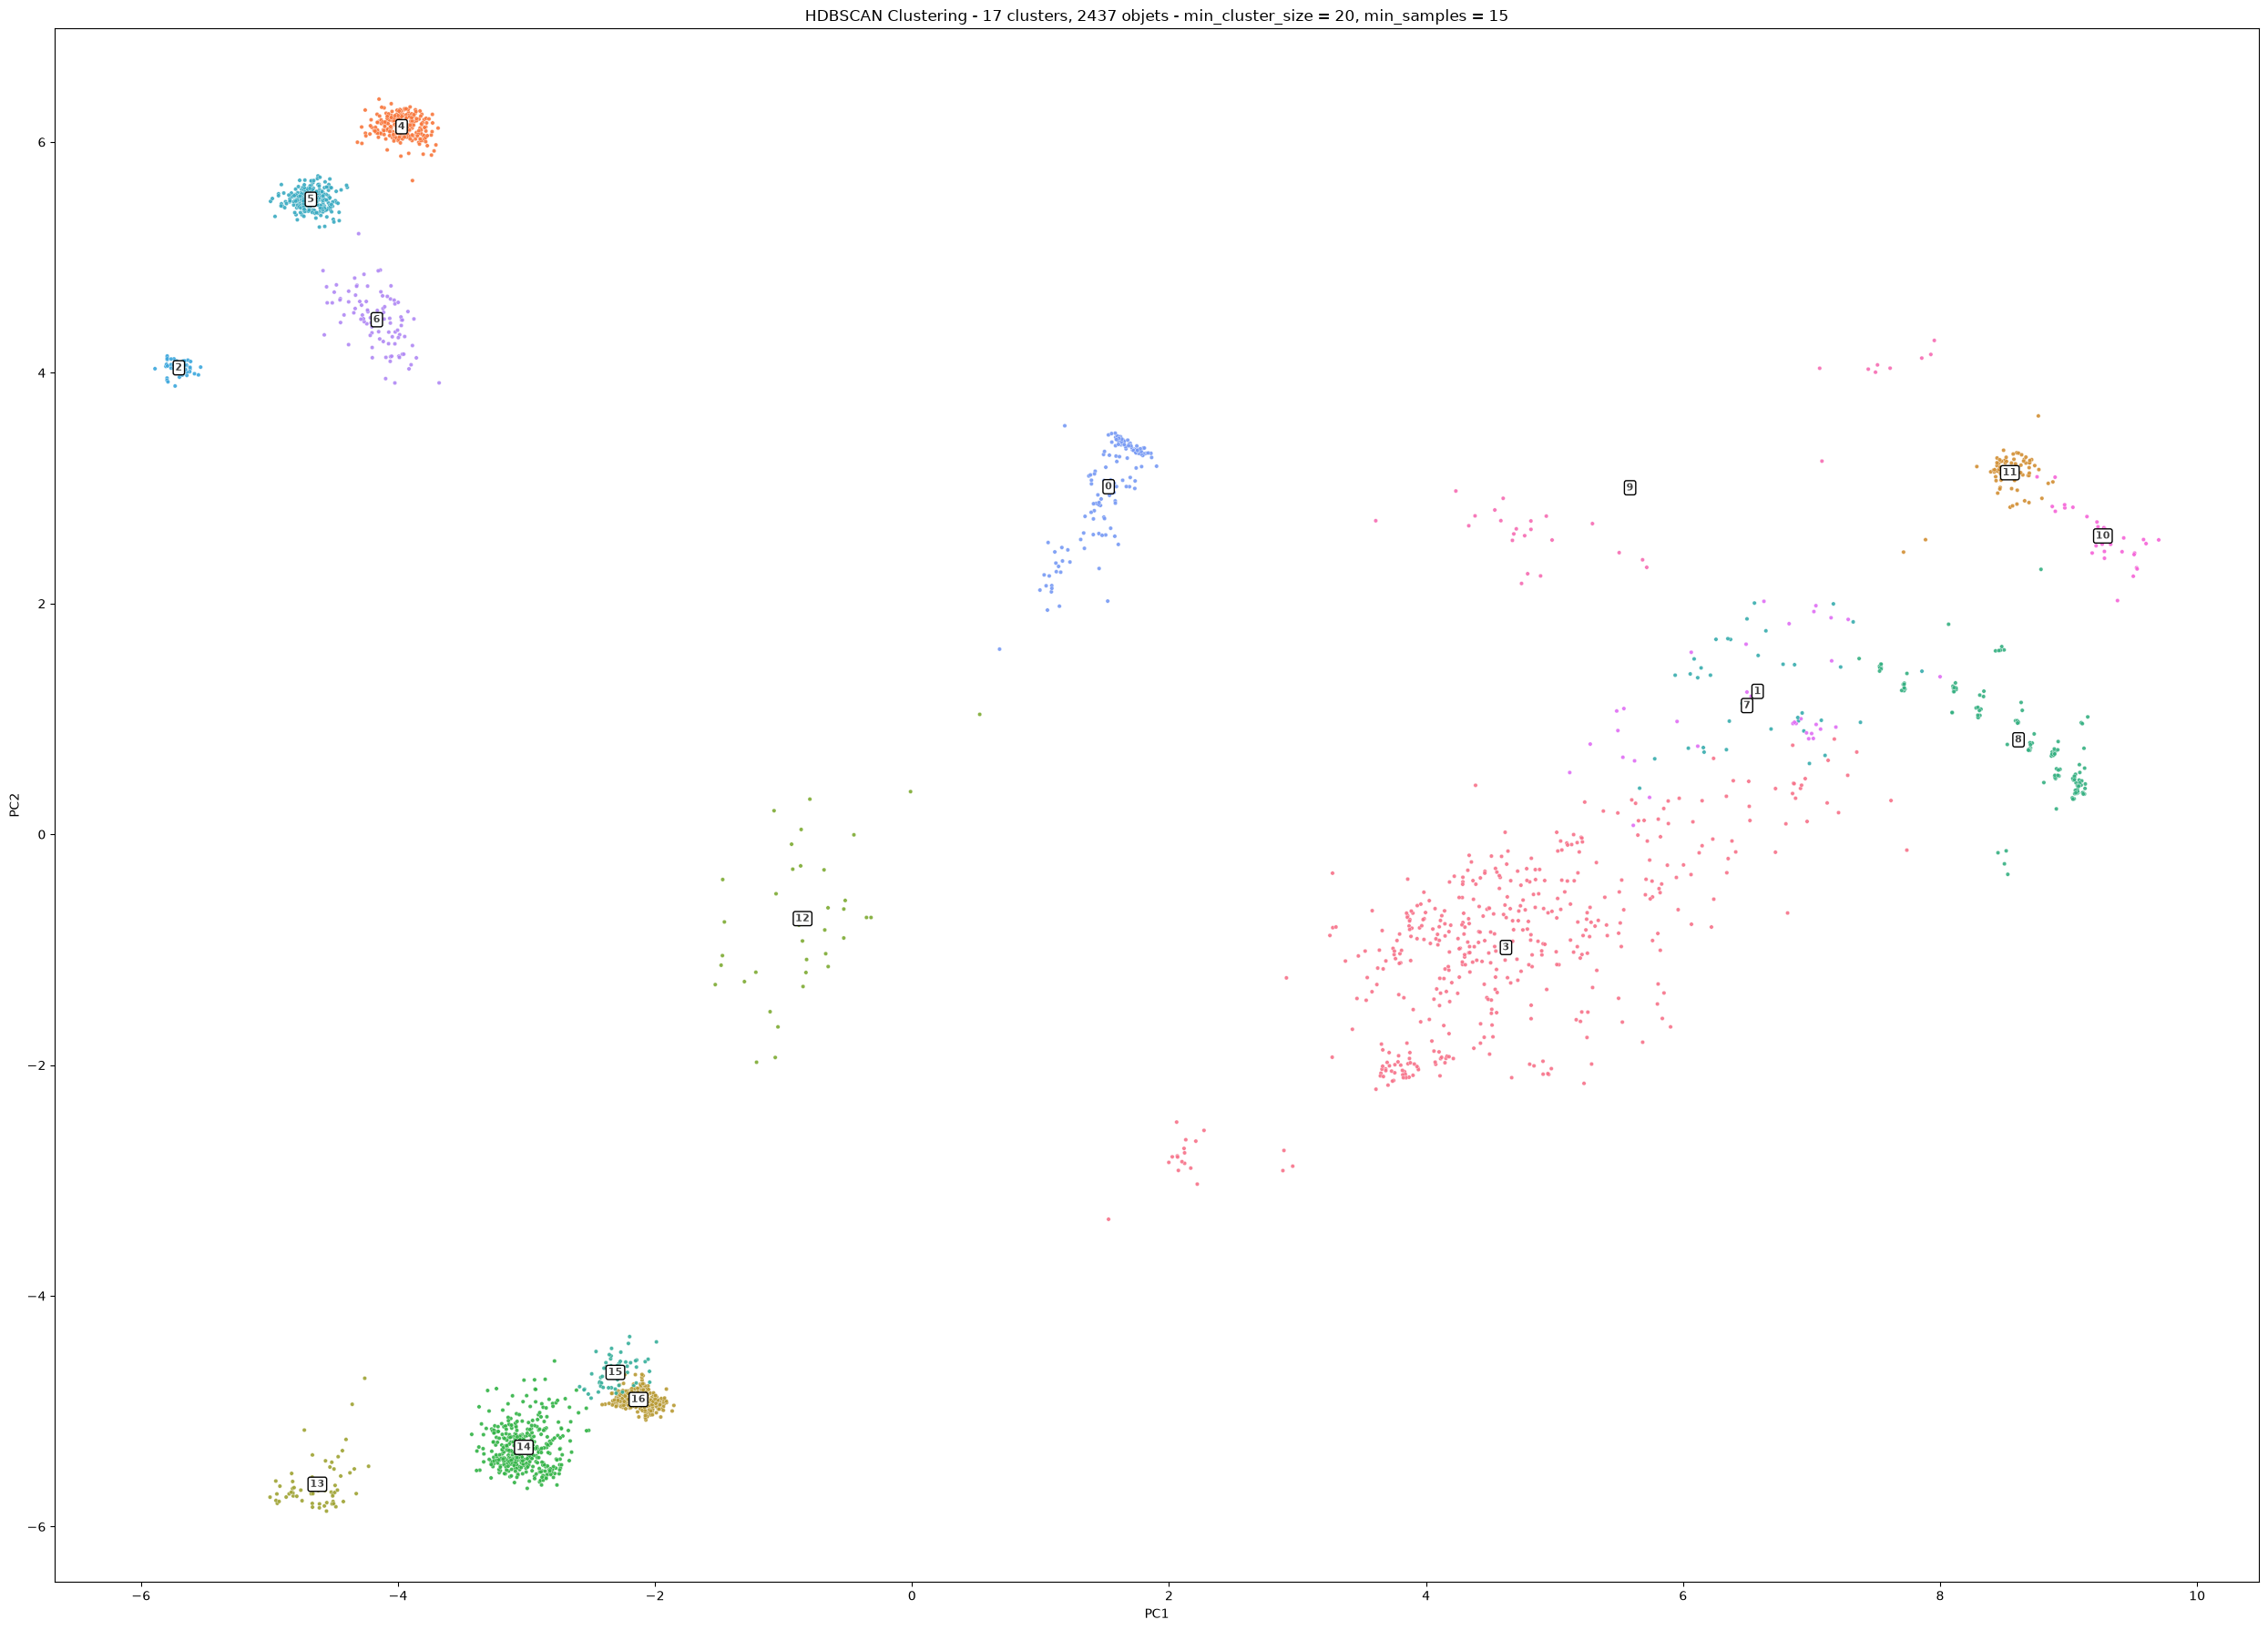

In [20]:
## on va maintenant tester la bonne généralisation du préentrainement en reproduisant le split train/val avec la seed de config

from ml.dataset import split_by_object

train_ids, val_ids = split_by_object(object_ids=norad_ids, val_split=0.2, seed=42)

X_obj_train = np.stack([out_64[n] for n in train_ids])
X_obj_val = np.stack([out_64[n] for n in val_ids])


X_scaled_train = StandardScaler().fit_transform(X_obj_train)
X_scaled_val = StandardScaler().fit_transform(X_obj_val)

labels_train = clusterer.fit_predict(X_scaled_train)
labels_val = clusterer.fit_predict(X_scaled_val)

mask_train = labels_train != -1
mask_val = labels_val != -1

X_scaled_train_clean = X_scaled_train[mask_train]
labels_train_clean = labels_train[mask_train]

X_scaled_val_clean = X_scaled_val[mask_val]
labels_val_clean = labels_val[mask_val]

viz_2d_on_clusters(X_scaled_train_clean, labels_train_clean)
viz_2d_on_clusters(X_scaled_val_clean, labels_val_clean)


In [21]:

norad_train_clean, norad_val_clean = [train_ids[i] for i in range(len(train_ids)) if mask_train[i]], [val_ids[i] for i in range(len(val_ids)) if mask_val[i]]
create_cluster_csv(norad_train_clean, labels_train_clean, 'train_norads')
create_cluster_csv(norad_val_clean, labels_val_clean, 'val_norads')

In [22]:
## on va tester différentes configuration de paramètres HDBSCAN

def hdbscan_params_cluster_test(X):
    score = 0 
    best_minclustersize = 0
    best_minsamples = 0
    for cluster_size in range(2,21,3) : 
        for samples in range(2,21, 3) : 
            clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=samples, gen_min_span_tree=True)
            labels = clusterer.fit_predict(X)
            dbcv = clusterer.relative_validity_
            if dbcv > score : 
                score = dbcv
                best_minclustersize = cluster_size
                best_minsamples = samples
    
    clusterer = hdbscan.HDBSCAN(min_cluster_size=best_minclustersize, min_samples=best_minsamples)
    labels = clusterer.fit_predict(X)
    mask = labels !=-1
    X_clean = X[mask]
    labels_clean = labels[mask]
    viz_2d_on_clusters(X_clean, labels_clean, min_cluster_size=cluster_size, min_samples=samples)



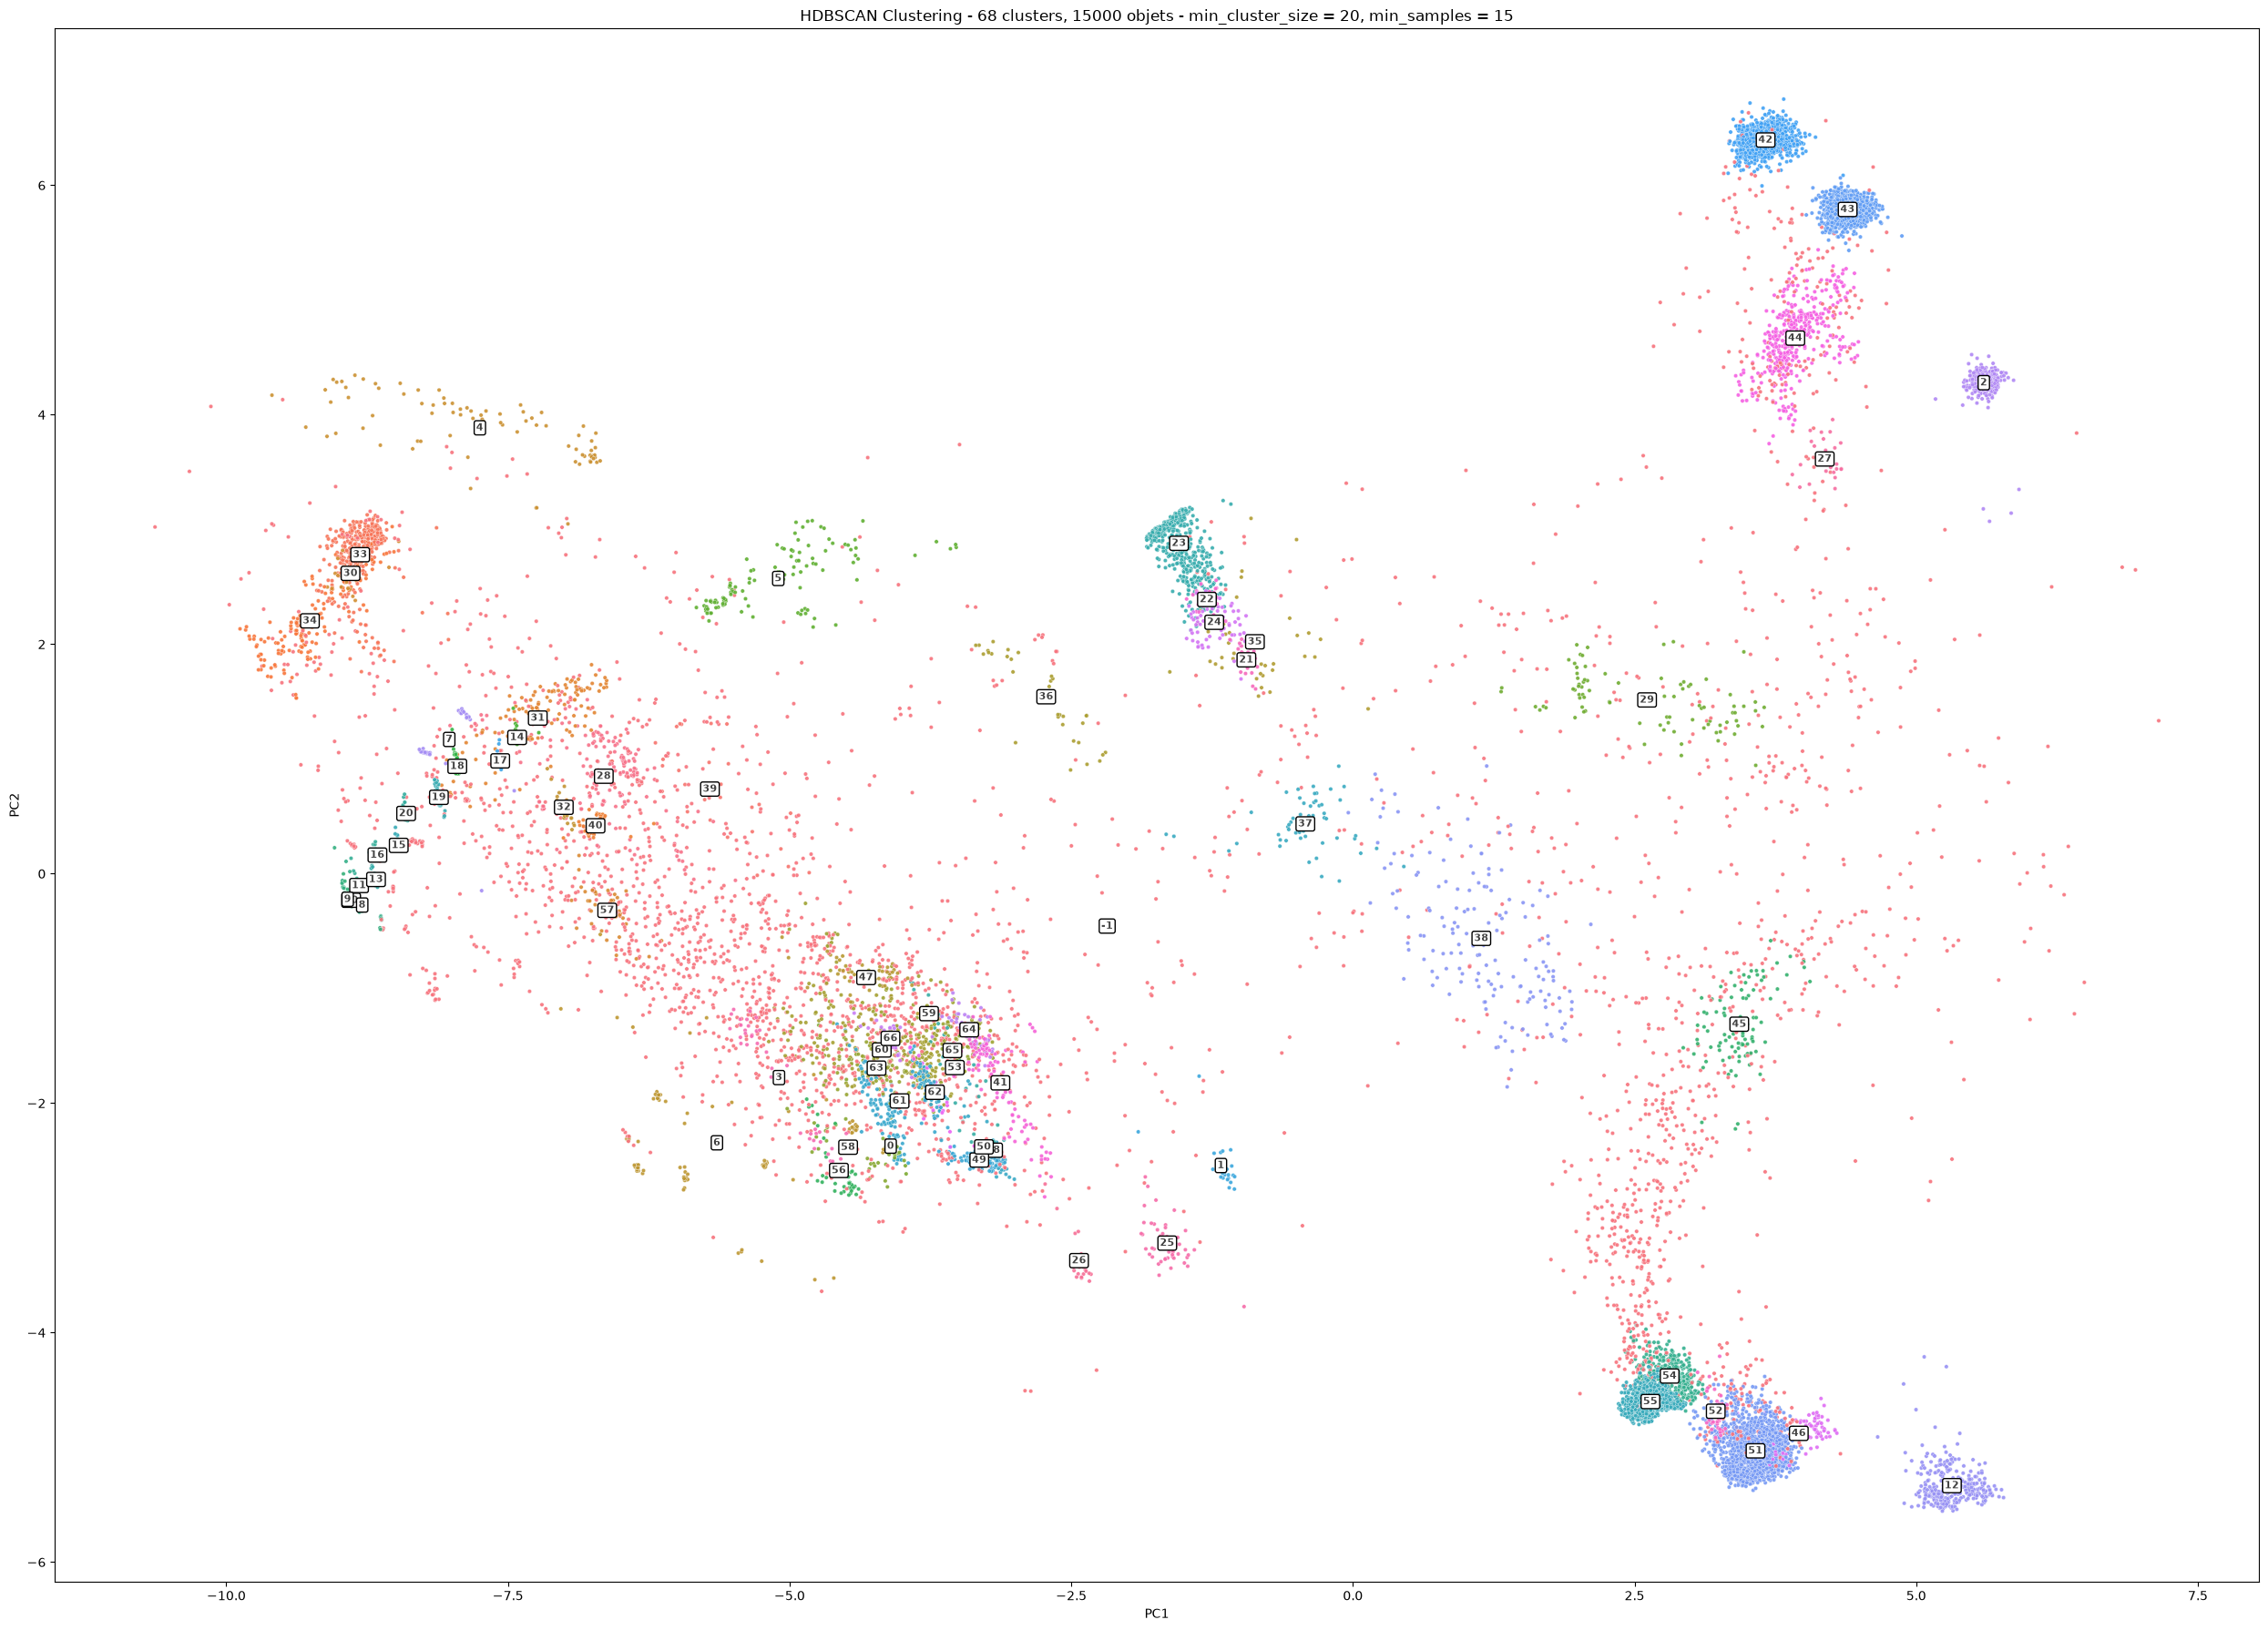

In [23]:

labels = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=15).fit_predict(X_scaled)

viz_2d_on_clusters(X_scaled, labels, min_cluster_size=20, min_samples=15)


In [24]:

## On charge le modèle MAEv2 de dimension 128 d'embedding 
base = Path.cwd()

ckpt_dir = Path(os.path.join(base, '..', '..', 'outputs', 'ml', 'pretrain', '2026-08-06_14-53-13', 'checkpoints', 'best.pt'))

device = torch.device("cpu")
pretrained_model, cfg, mean, scale = load_checkpoint(ckpt_dir, device)
print(pretrained_model)


TimeSeriesMAE(
  (patch_embedding): PatchEmbedding(
    (proj): Conv1d(11, 128, kernel_size=(12,), stride=(12,))
  )
  (encoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(8, 128)
  )
  (decoder_pos_embedding): LearnedPositionalEmbedding(
    (PE): Embedding(9, 64)
  )
  (encoder_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (MSA): MultiHeadSelfAttention(
        (query_matrix): Linear(in_features=128, out_features=128, bias=True)
        (key_matrix): Linear(in_features=128, out_features=128, bias=True)
        (value_matrix): Linear(in_features=128, out_features=128, bias=True)
        (output_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (MLP): MLP(
        (dense1): Linear(in_features=128, out_features=512, bias=T

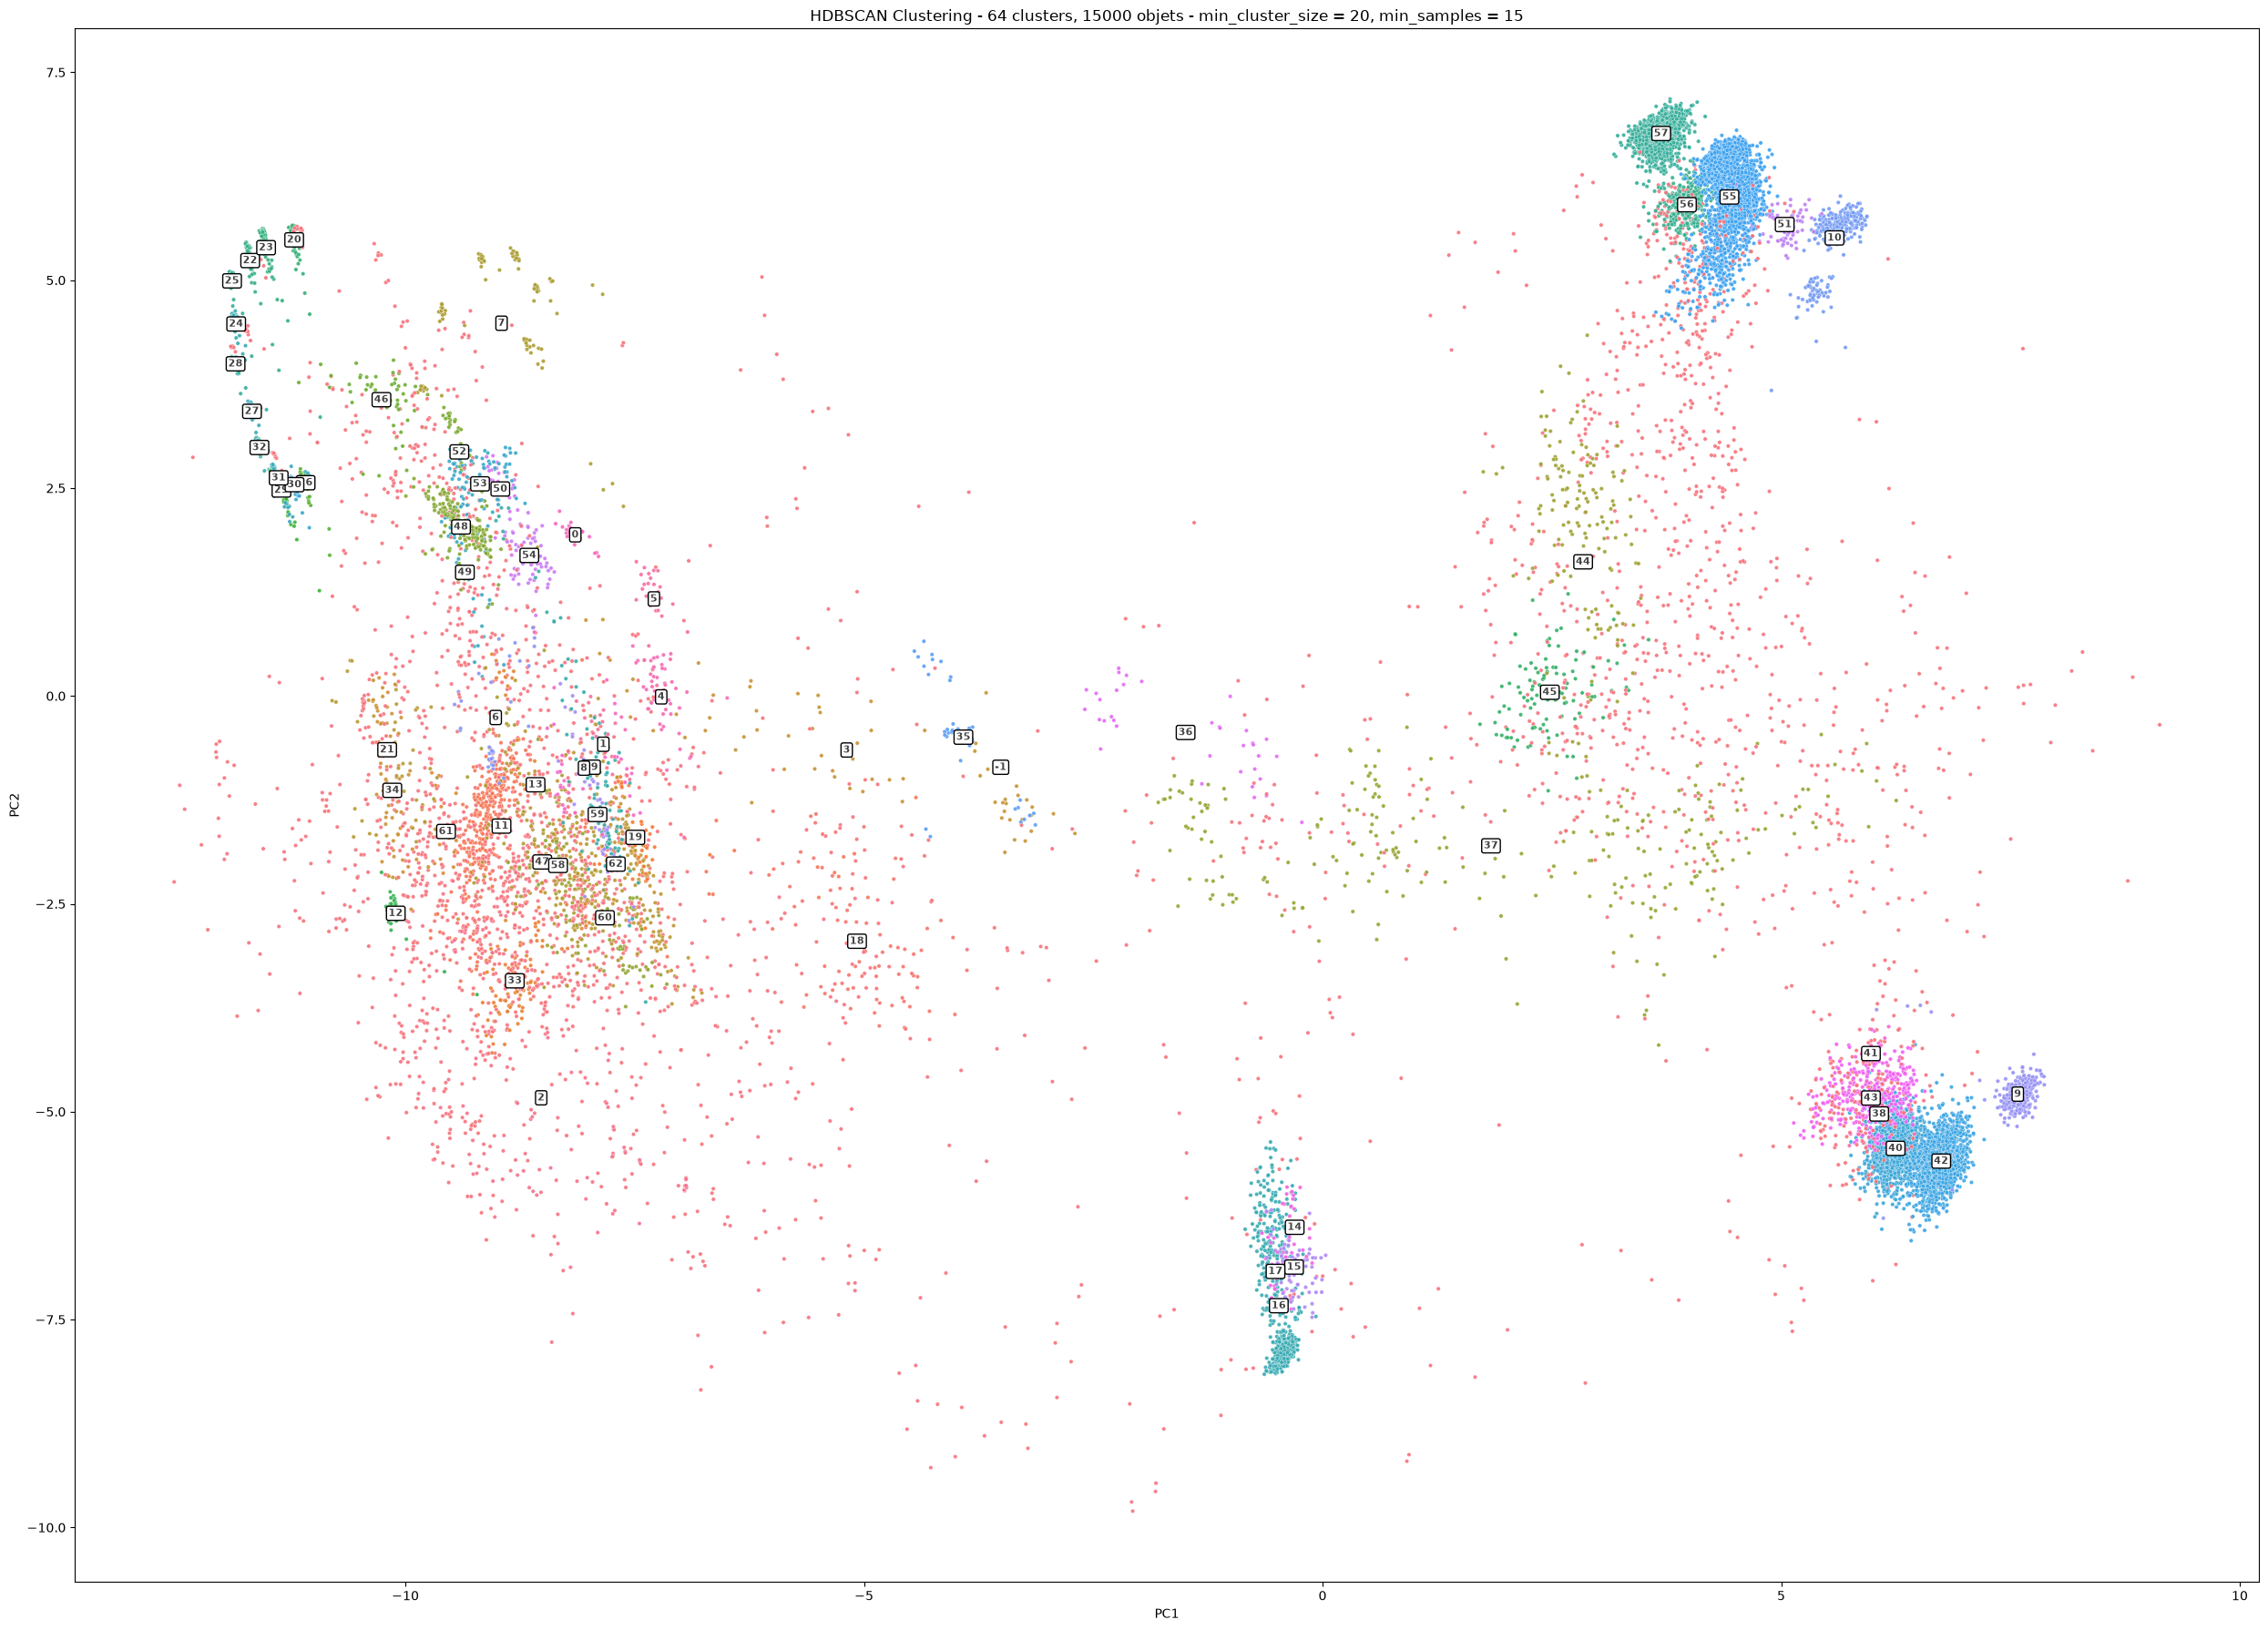

In [ ]:

encoder_state_dict = pretrained_model.encoder_state_dict()

backbone_MAEv2 = VanillaViT(
    n_features = 11, 
    n_epochs= 96, 
    patch_size=12, 
    embed_dim=128,
    n_attn_heads=4,
    n_blocks=12,
    expansion_factor=4,
    dropout_rate=0.1
)

missing, unexpected = backbone_MAEv2.load_state_dict(encoder_state_dict, strict=False) # les poids sont bien chargés. 

out_128 = load_data_and_inference(backbone_MAEv2)

norad_ids = list(out_128.keys())

X_obj = np.stack([out_128[n] for n in norad_ids])
X_scaled = StandardScaler().fit_transform(X_obj)
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=15)
labels = clusterer.fit_predict(X_scaled)

viz_2d_on_clusters(X_scaled, labels)


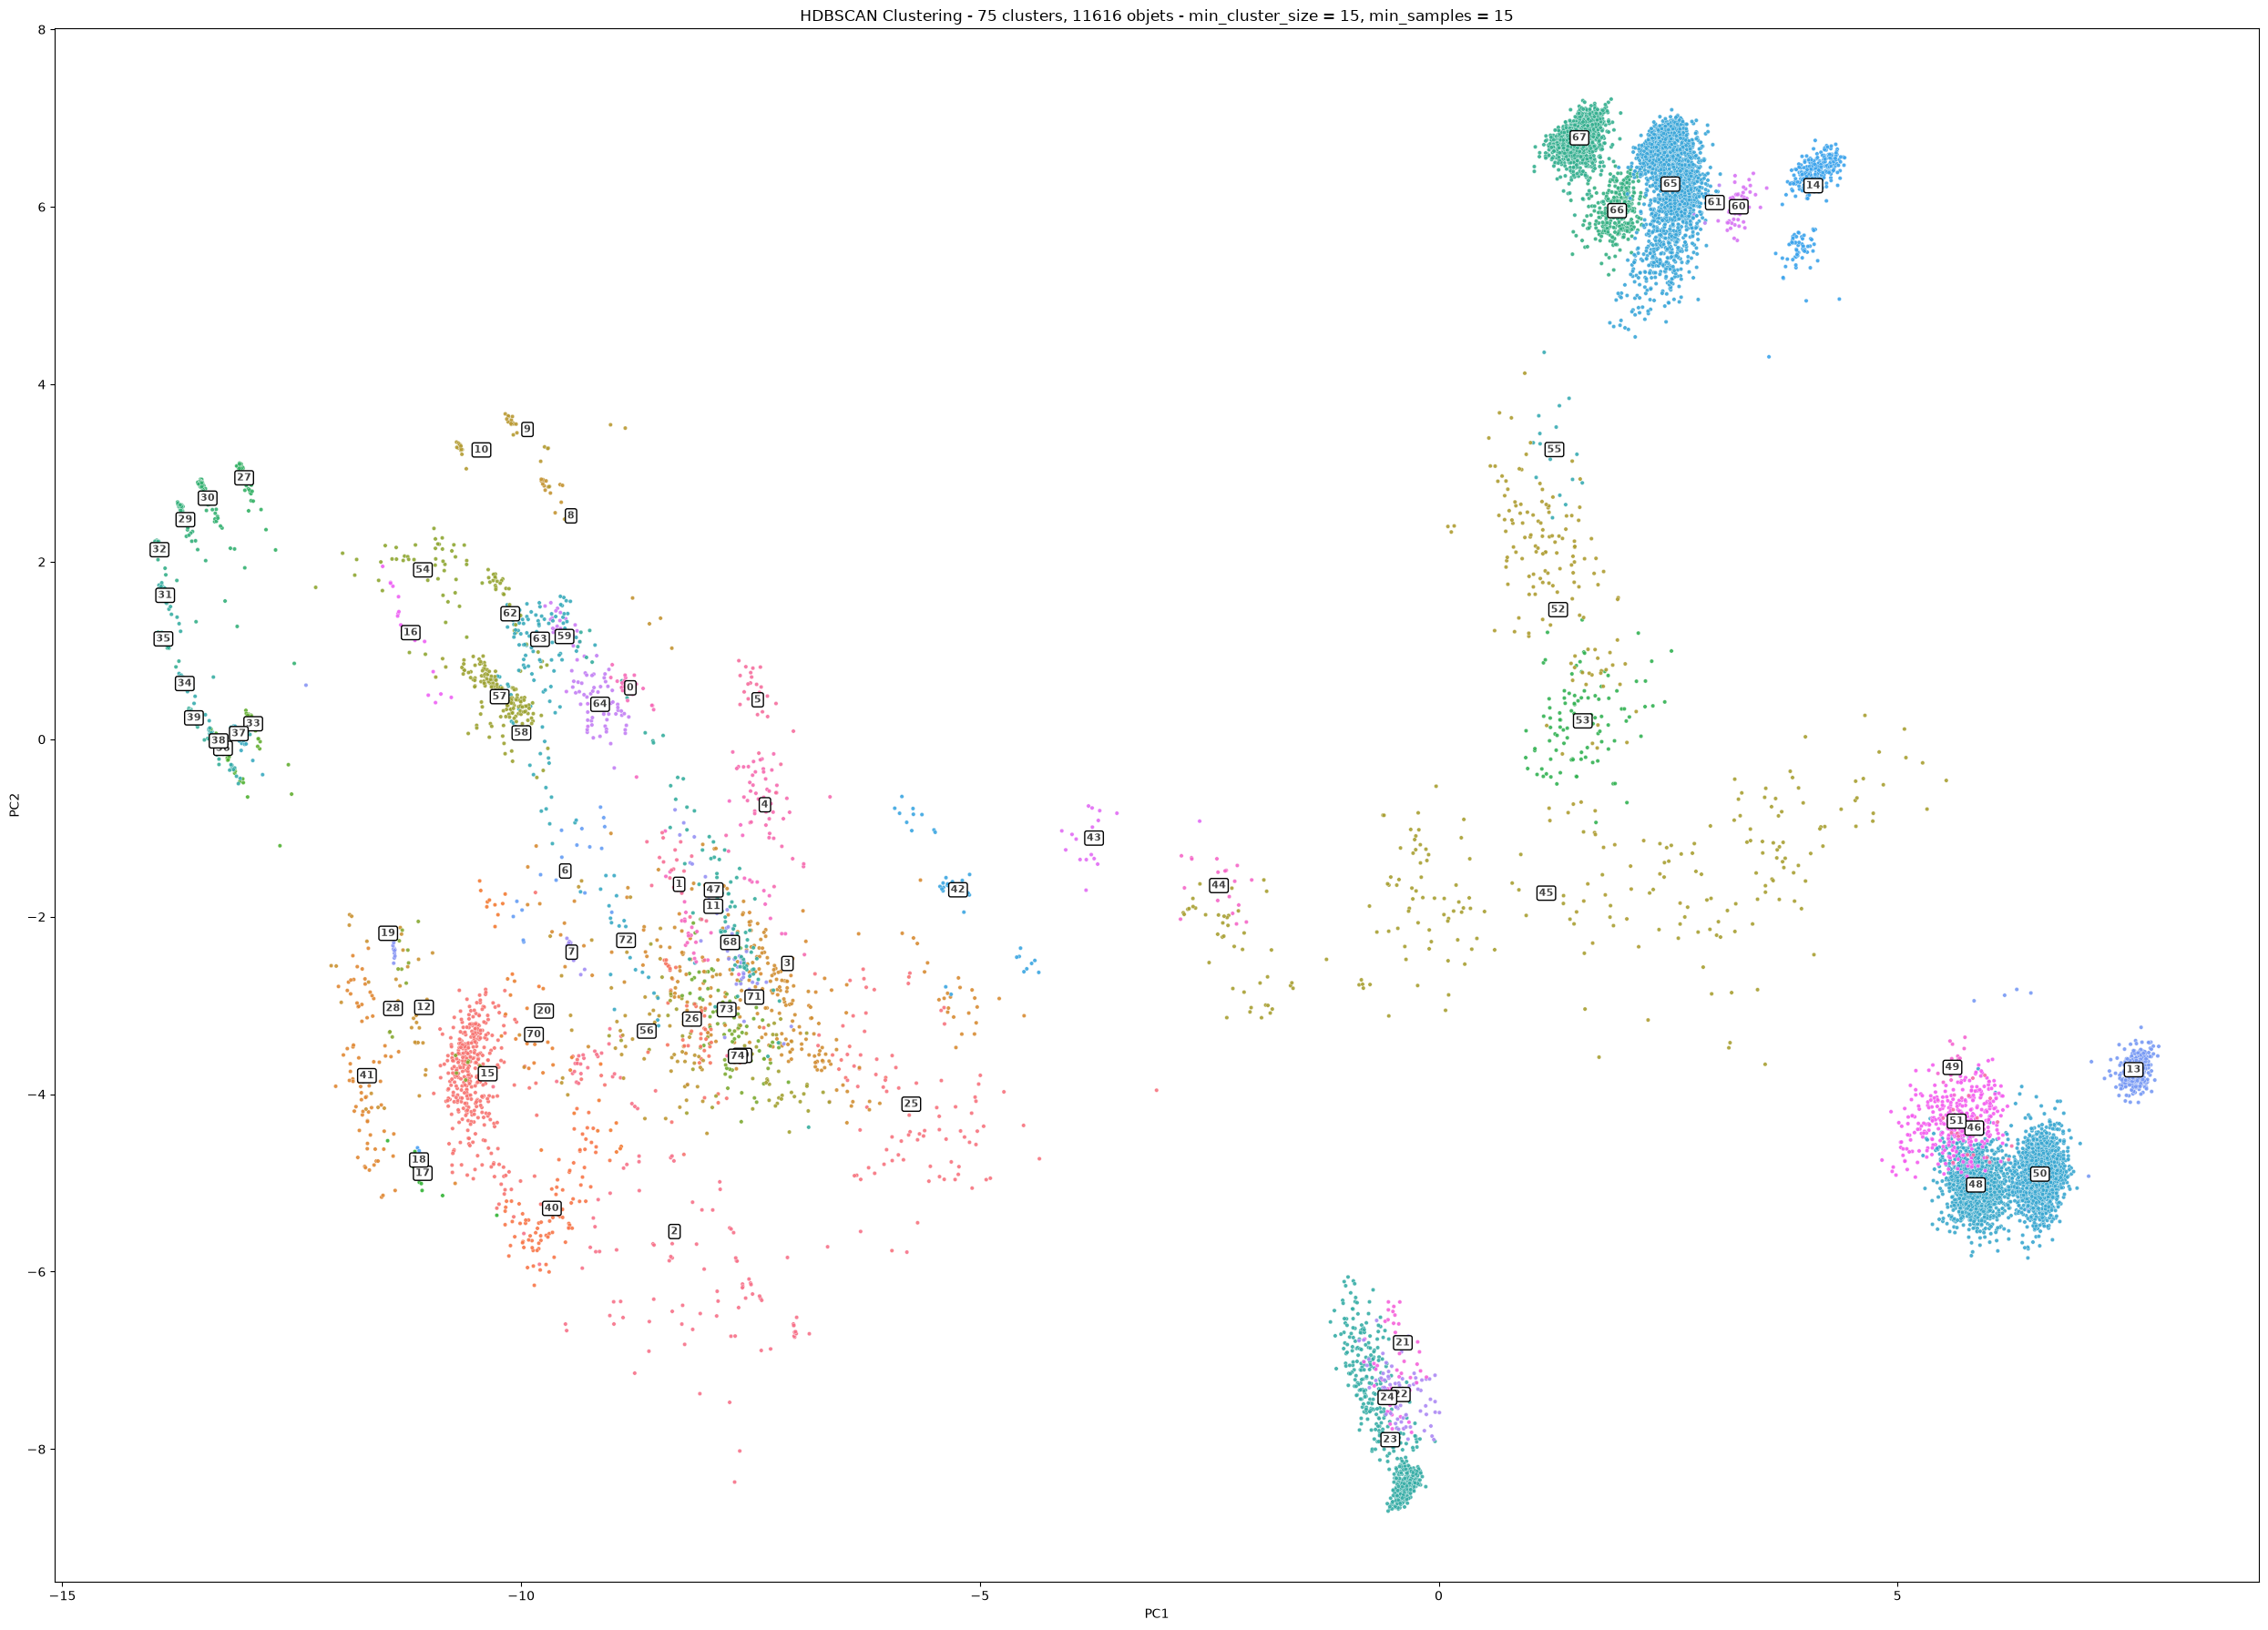

In [64]:

## Params de clusterisation, ils sont choisis physiquement en fonction des plus petits lancements connus (quelques satellites)

min_cluster_size = 15
min_samples = 15

clusterer = hdbscan.HDBSCAN(min_cluster_size, min_samples)
labels = clusterer.fit_predict(X_scaled)

mask = labels!=-1
X_clean = X_scaled[mask]
labels_clean = labels[mask]
viz_2d_on_clusters(X_clean, labels_clean, min_cluster_size, min_samples)
create_cluster_csv(norad_ids, labels, name=f'15000_spacetrack_128D_MCS{min_cluster_size}_MS{min_samples}_OPTIM')


## Analyse de l'augmentation de la dimension d'embedding 

--- 

Run 128-D : Architecure MAEv2, 15000 objets, sur 200 epochs.

HDBSCAN : après un scan des paramètres 
$$
min cluster size \in \{ 5, \dots, 20 \}  \quad  min samples \in \{ 5, \dots, 15 \}
$$
on retient 15 et 15. 

Par la suite on fait référence à la clusterisation sauvée dans le csv nommé 'cluster_leo_15000_spacetrack_128D_MCS15_MS15_OPTIM

On obtient 75 clusters. + 3384 objets classés en bruit.

Structure en 3 étages : 
- les méga-constellations : (9 grands clusters, environ 7900 objets). Dont 4 coquilles Starlink dominantes  : clusters 65 = 2023-2025, cluster 50 = , 67, 48
